### $$\text{INTERPRETABILIDAD DE MODELOS}$$

Orden cuaderno: 🔲codificado 🔲ejecutado

> ✅🅿 0. Importación de librerías

> ✅🅿 1. carga y limpieza de datos

> ✅🅿 2. Entrenamiento de modelos

> ✅🅿 3. Feature Importances - Interpretabilidad global

> ✅🅿 4. SHAP - Tree Explainer

> ✅🅿 5. Interpretabilidad local

> 🔲🅿 6. Conclusiones

# 0. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate

# Preprocesamiento y Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


In [2]:
# Interpretabilidad
from sklearn.inspection import PartialDependenceDisplay
import lime
import lime.lime_tabular
import shap

c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

# 1. carga y limpieza de datos

Leer archivo con df_trabajo:

In [4]:
dftrabajo = pd.read_csv('../data/df_trabajo_sesiones.csv', sep=",")

In [5]:
dftrabajo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22284 entries, 0 to 22283
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pais                 22284 non-null  object 
 1   num_visitas          22284 non-null  int64  
 2   numero_modelos       22284 non-null  int64  
 3   pagina_mas_visitada  22284 non-null  object 
 4   precio_maximo        22284 non-null  int64  
 5   precio_promedio      22284 non-null  float64
 6   visitaspag1trousers  22284 non-null  float64
 7   visitaspag2skirts    22284 non-null  float64
 8   visitaspag3blouses   22284 non-null  float64
 9   visitaspag4sales     22284 non-null  float64
 10  target               22284 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 1.9+ MB


Pipelines:

In [6]:
numeric_features = ['num_visitas', 'numero_modelos', 'precio_maximo', 'precio_promedio', 'visitaspag1trousers', 'visitaspag2skirts', 'visitaspag3blouses']

# Seleccionar automáticamente todas las columnas 'object' como categóricas
categorical_features = dftrabajo.select_dtypes(include=['object', 'category']).columns.tolist()

# Asegurarnos de que las numéricas no estén en la lista de categóricas
categorical_features = [col for col in categorical_features if col not in numeric_features and col != 'target' and col != 'visitaspag4sales']

print(f"Features/variables Numéricas: {numeric_features}")
print(f"Features/variables Categóricas: {categorical_features}")

Features/variables Numéricas: ['num_visitas', 'numero_modelos', 'precio_maximo', 'precio_promedio', 'visitaspag1trousers', 'visitaspag2skirts', 'visitaspag3blouses']
Features/variables Categóricas: ['pais', 'pagina_mas_visitada']


Transformadores:

In [7]:
# Crear el transformador para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputar NAs con la mediana
    ('scaler', StandardScaler())                 # Escala los datos.
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputar NAs con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))   # Aplicar One-Hot Encoding
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Dejar pasar cualquier columna no especificada directamente
)

preprocessor
print("\n\nPreprocesador creado exitosamente!")



Preprocesador creado exitosamente!


División de datos:

In [8]:
X = dftrabajo.drop(['target', 'visitaspag4sales'], axis=1)
y = dftrabajo['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de X Train: {X_train.shape}")
print(f"Tamaño de X Test: {X_test.shape}")

print(f"Tamaño de y Train: {y_train.shape}")
print(f"Tamaño de y Test: {y_test.shape}")

Tamaño de X Train: (17827, 9)
Tamaño de X Test: (4457, 9)
Tamaño de y Train: (17827,)
Tamaño de y Test: (4457,)


# 2. Entrenamiento de modelos

XGBOOST entrenado con los mejores hiperparámetros encontrados por `RandomizedSearch` (cuaderno `2.optimizacion_hiperparametros.ipynb`):

In [9]:
# Cálculo de 'scale_pos_weight' para ingresar como parámetro en modelos de boosting
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Definir pipeline de entrenamiento de modelo
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        learning_rate=np.float64(0.1642703315240835), 
        max_depth=3, 
        min_split_loss=2, 
        n_estimators=406,
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss', # Función de pérdida/costo a minimizar
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight # Ayudar con el desbalanceo
    ))
])

# Entrenar el pipeline
print("Entrenando el Pipeline de XGBoost...")
xgb_pipeline.fit(X_train, y_train)
print("Entrenamiento completado.")

Scale Pos Weight: 1.99
Entrenando el Pipeline de XGBoost...
Entrenamiento completado.


In [10]:
# Evaluar modelo
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Reporte de Clasificación (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))

# Guardar métricas en objetos
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, pos_label=1)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, pos_label=1)
xgb_recall = recall_score(y_test, y_pred_xgb, pos_label=1)

print("\n--- Métricas XGBoost guardadas ---")


--- Reporte de Clasificación (XGBoost) ---
              precision    recall  f1-score   support

           0       0.82      0.66      0.73      2967
           1       0.51      0.71      0.60      1490

    accuracy                           0.68      4457
   macro avg       0.67      0.69      0.66      4457
weighted avg       0.72      0.68      0.68      4457


--- Métricas XGBoost guardadas ---


# 3. Feature Importances - Interpretabilidad global

In [13]:
def plot_feature_importance(pipeline, top_n=15):
    try:
        # Extraer el modelo y el preprocesador del pipeline
        model = pipeline.named_steps['model']
        preprocessor = pipeline.named_steps['preprocessor']
        
        # Obtener los nombres de las features después del OneHotEncoding
        # 'cat' es el nombre que le dimos al transformador categórico
        ohe_features = preprocessor.named_transformers_['cat']\
                                   .named_steps['onehot']\
                                   .get_feature_names_out(categorical_features)
        
        # Combinar con los nombres de las features numéricas
        # 'num' es el nombre del transformador numérico
        feature_names = np.concatenate([numeric_features, ohe_features])
        
        # Obtener la importancia
        # 'hasattr' evalúa si el objeto 'model' tiene un atributo 
        # o método llamado 'feature_importances_'
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            model_name = model.__class__.__name__
        else:
            print("Este modelo no tiene 'feature_importances_'.")
            return

        # Crear un DataFrame de importancia
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)
        
        # Graficar
        plt.figure(figsize=(10, 8))
        sns.barplot(data=importance_df.head(top_n), x='importance', y='feature')
        plt.title(f'Top {top_n} Feature Importances ({model_name}), Métrica GINI')
        plt.show()
        
    except Exception as e:
        print(f"Error al obtener feature importance: {e}, Métrica GINI")
        print("Es posible que el pipeline no esté entrenado o la estructura no coincida.")

> Importancia de variables del modelo **XGBoost**

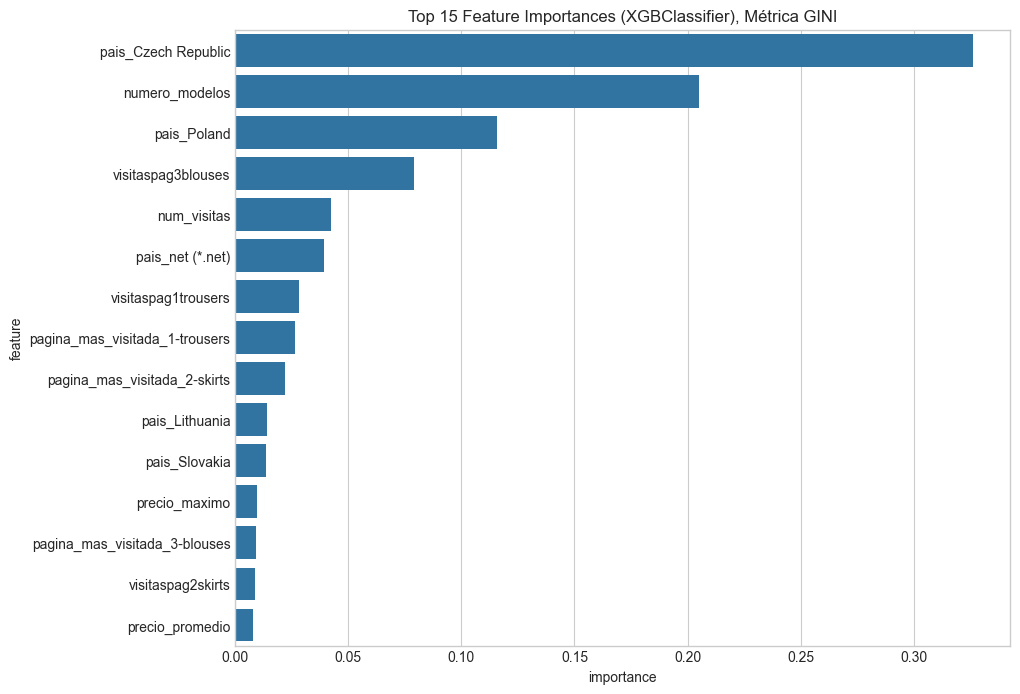

In [14]:
plot_feature_importance(xgb_pipeline)

La variable con la mayor importancia (61%) fue la variable binaria `pais_Czech Republic`, indicando que las sesiones de usuario registradas desde República Checa tienden a registrar compras con más frecuencia.

# 4. SHAP - Tree Explainer

## 4.1. Cálculo de SHAP Values

In [15]:
# Inicializar JS
shap.initjs()

In [24]:
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 1. **Transforma X_test usando el preprocesador del pipeline**
# Esto convierte las columnas 'object' en numéricas one-hot encoded y así 
# el comando 'explainer.shap_values' funcionará correctamente.
X_test_processed_array = xgb_pipeline.named_steps['preprocessor'].transform(X_test)

# 2. Crear un DataFrame de pandas con los nombres de las features
X_test_processed_df = pd.DataFrame(
    X_test_processed_array,
    columns=feature_names,
    index=X_test.index
)

# Calculando SHAP values para XGBoost classifier
print("Calculando SHAP values para XGBoost classifier...")
explainer = shap.TreeExplainer(xgb_pipeline.named_steps['model'])

shap_values = explainer.shap_values(X_test_processed_df)

# Corrección de formato para versiones nuevas de SHAP (si devuelve lista)
if isinstance(shap_values, list):
    shap_values = shap_values[1] # Tomamos la clase positiva (Ingreso a página de compra 'sales')
    
print("Valores SHAP calculados.")

Calculando SHAP values para XGBoost classifier...
Valores SHAP calculados.


## 4.2. Gráficos

### a. Beeswarm Plot

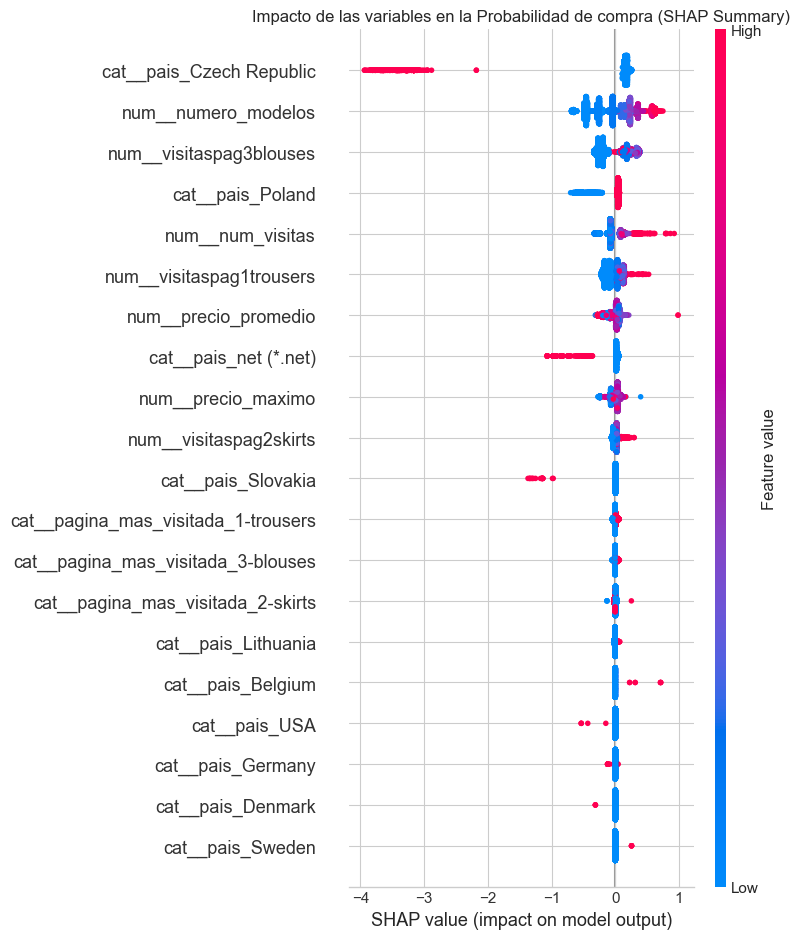

In [26]:
plt.title("Impacto de las variables en la Probabilidad de compra (SHAP Summary)")

shap.summary_plot(
    shap_values,
    features=X_test_processed_df,
    feature_names=X_test_processed_df.columns,
    max_display=20, # O el número que desees
    show=False # Siempre usa show=False si vas a añadir pyplot.tight_layout()
)
plt.tight_layout()
plt.show()

### b. Absolute Mean SHAP

Hasta el momento, `SHAP_values` era un array netamente numérico, por tal razón, `shap.plots.bar` no podía interpretarlo ni asociarlo a las etiquetas/nombres de las variables.

In [38]:
print("Creando el objeto shap.Explanation...")

# 1. Crear el objeto Explanation
# Es crucial pasar:
# - values: El array numpy de los valores SHAP.
# - data: El DataFrame que contiene los valores originales de las features (¡usamos el DataFrame transformado!).
# - feature_names: La lista de nombres de las features.
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_processed_df.values,  # Pasamos los valores del DataFrame
    feature_names=X_test_processed_df.columns.tolist() # Pasamos los nombres de las columnas
)

Creando el objeto shap.Explanation...


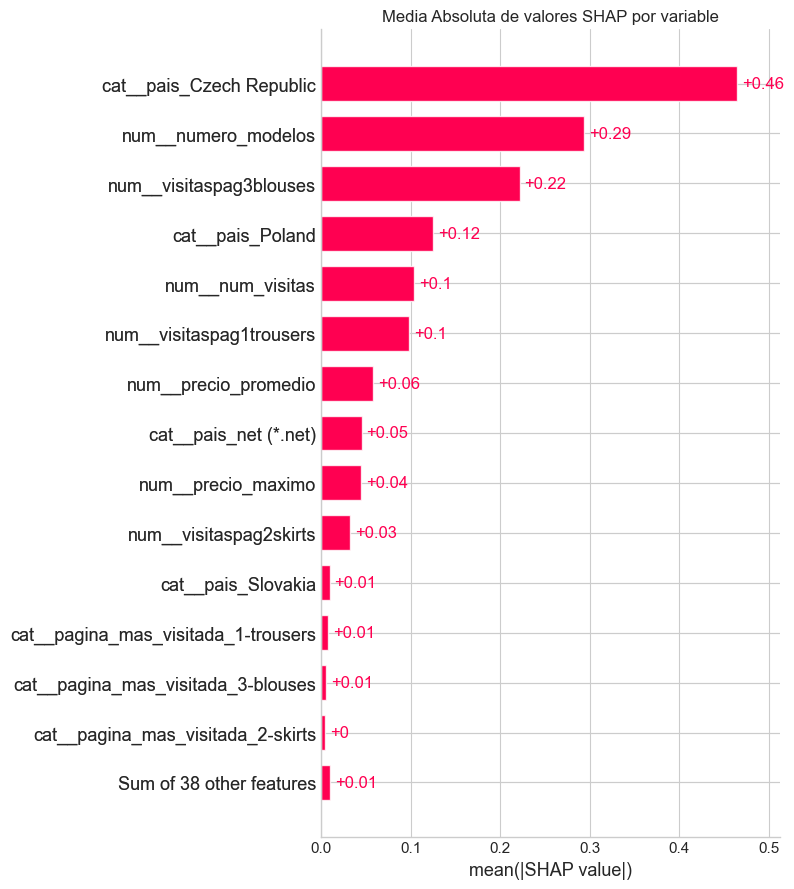

In [39]:
plt.title("Media Absoluta de valores SHAP por variable")
shap.plots.bar(shap_explanation, max_display=15, show=False)
plt.tight_layout()
plt.show()

### 🚧c. Stacked Force Plot

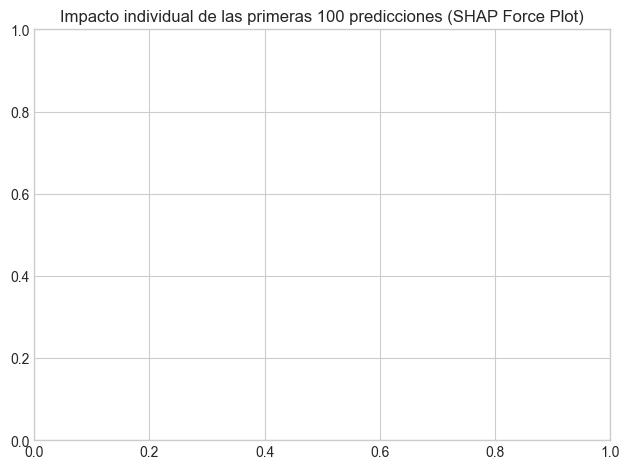

In [40]:
plt.title("Impacto individual de las primeras 100 predicciones (SHAP Force Plot)")
shap.plots.force(shap_explanation[0:100])
plt.tight_layout()
plt.show()

In [37]:
# Revisa el valor base:
base_value = explainer.expected_value
print(f"Valor Base del Explainer: {base_value}")

Valor Base del Explainer: -0.00573468254879117


### d. Dependence Plot

In [69]:
variable1 = 'num__numero_modelos'
variable2 = 'num__visitaspag3blouses'

> **Gráfico 1**

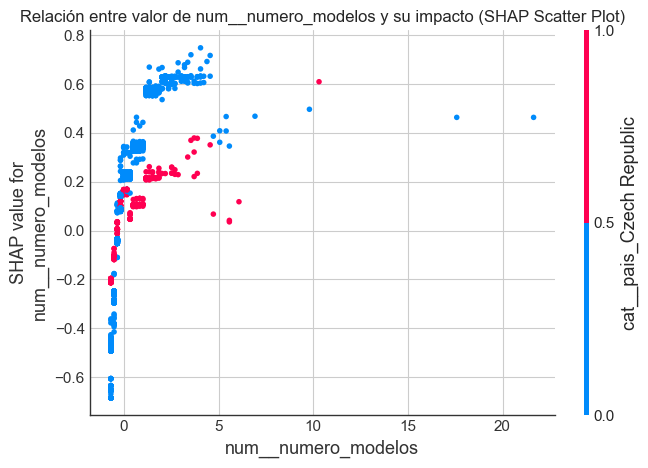

In [75]:
shap.dependence_plot(
    variable1, 
    shap_values, 
    X_test_processed_df,
    show=False
)
plt.title(f"Relación entre valor de {variable1} y su impacto (SHAP Scatter Plot)")
plt.show()

> **Gráfico 2**

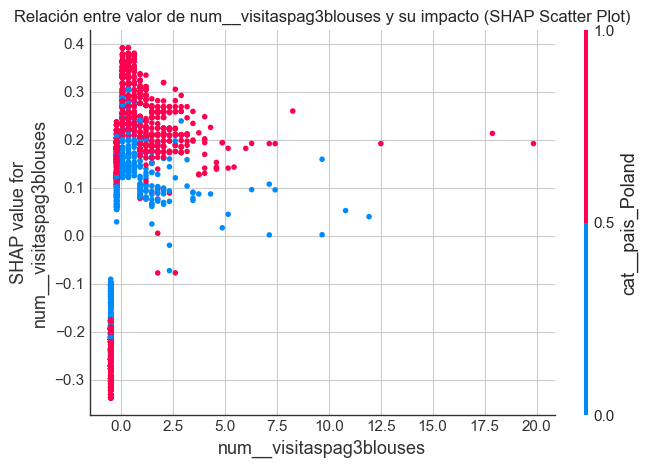

In [76]:
shap.dependence_plot(
    variable2, 
    shap_values, 
    X_test_processed_df,
    show=False
)
plt.title(f"Relación entre valor de {variable2} y su impacto (SHAP Scatter Plot)")
plt.show()

> **Gráfico 3**

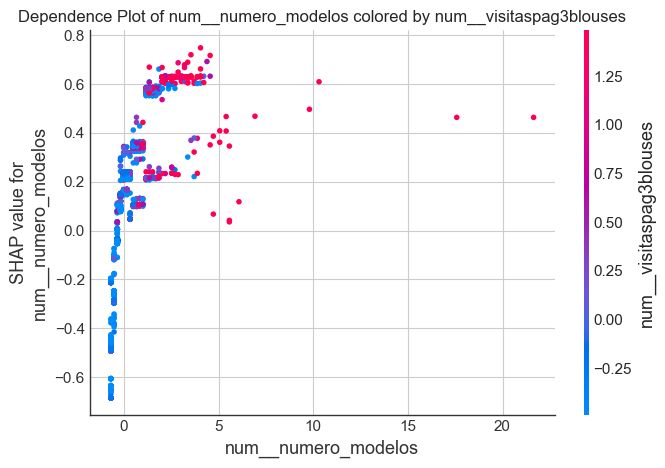

In [74]:
shap.dependence_plot(
    variable1, 
    shap_values, 
    X_test_processed_df, 
    interaction_index=variable2,
    show=False
)
plt.title(f"Dependence Plot of {variable1} colored by {variable2}")
plt.show()

# 5. Interpretabilidad local

Encontrar en primer lugar la sesión (punto de datos) con mayor probabilidad de entrar a la página de compras (clase positiva):

In [44]:
probs = xgb_pipeline.predict_proba(X_test)[:, 1]

max_probs_idx = np.argmax(probs)
sesion_max_prob = X_test.iloc[max_probs_idx]

print(f"Sesión con mayor probabilidad de compra (sales): {max_probs_idx}")
print(f"Probabilidad de la sesión de entrar a página de compras 'sales': {probs[max_probs_idx]: .4f}")

Sesión con mayor probabilidad de compra (sales): 1330
Probabilidad de la sesión de entrar a página de compras 'sales':  0.9145


## 5.1. Gráficos SHAP

### a. SHAP Waterfall Plot

Generar a continuación el `Waterfall Plot` para este caso individual:

In [53]:
# 1. Extraer la fila de datos transformada y convertirla a array NumPy
# ¡Esta línea es la clave!
sesion_max_prob_array = X_test_processed_df.iloc[max_probs_idx].values

print(f"Longitud de sesion_max_prob_array: {len(sesion_max_prob_array)}")

Longitud de sesion_max_prob_array: 52


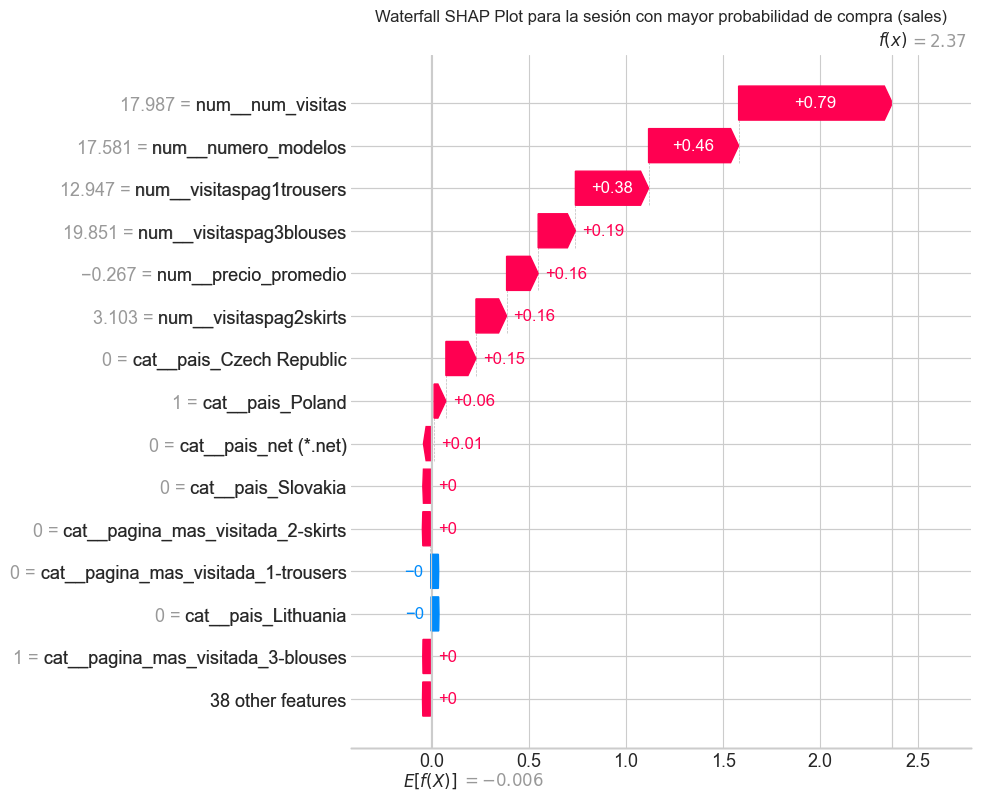

In [54]:
plt.title(f"Waterfall SHAP Plot para la sesión con mayor probabilidad de compra (sales)")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[max_probs_idx], 
        base_values=explainer.expected_value, 
        data=sesion_max_prob_array,
        feature_names=X_test_processed_df.columns.tolist()
    ),
    max_display=15,
    show=False
)

plt.show()

En este caso, el gráfico de Cascada (Waterfall Plot) no muestra directamente la probabilidad de compra (0.9145) en sus unidades. Muestra las contribuciones de las variabloes al log-odds (logaritmo de las probabilidades), que es la unidad natural del modelo XGBoost (y en general, de los modelos basados en boosted trees que usan la función de pérdida logarítmica).

Para convertir los valores del log-odds a la probabilidad, se debe usar la función:

$$Probabilidad = \frac{1}{1 + e^{-\hat{y}}}$$

De esta manera:

- Si $f(X) = 2.37$, entonces $probabilidad = 0.9145$
- Si $E[f(X)] = -0.006$, entonces $probabilidad = 0.4985$


### 🚧b. SHAP Force plot

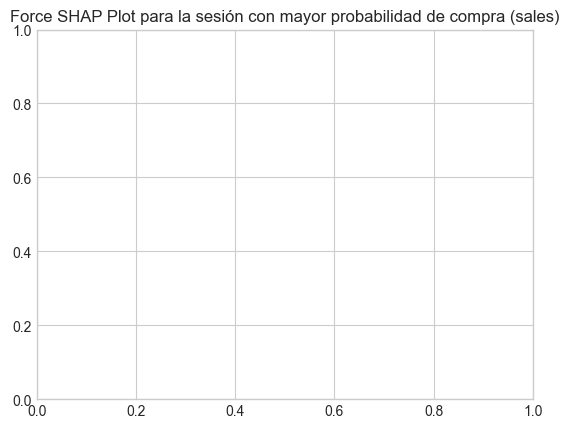

In [57]:
plt.title("Force SHAP Plot para la sesión con mayor probabilidad de compra (sales)")

shap.plots.force(
    shap.Explanation(
        values=shap_values[max_probs_idx], 
        base_values=explainer.expected_value, 
        data=sesion_max_prob_array,
        feature_names=X_test_processed_df.columns.tolist()
    ),
    
    show=False
)

plt.show()

## 5.2. Gráficos LIME

Nota: LIME necesita los datos como un array de NumPy (que es lo que 'preprocessor.transform' devuelve por defecto)

In [59]:
print("Transformando X_train a formato numérico para LIME...")

# Aplicar la transformación a X_train
# Esto convierte 'pais' y 'pagina_mas_visitada' a columnas One-Hot Encoded.
X_train_processed_array = preprocessor.transform(X_train) 

# 2. Obtener los nombres de las features transformadas para LIME (esto es CRUCIAL)
feature_names_transformed = preprocessor.get_feature_names_out().tolist()
print("Transformación completada para LIME.")

Transformando X_train a formato numérico para LIME...
Transformación completada para LIME.


In [60]:
variable1 = 'num__numero_modelos' # Ajusta el nombre si usaste StandardScaler
variable2 = 'cat__visitaspag3blouses' # Ajusta el nombre al formato One-Hot Encoded

Nota Importante sobre `feature_names`: Si se usa LIME sin proporcionar todos los nombres de las features (`feature_names`), puede dar errores o explicaciones incorrectas. Se deben pasar los 52 nombres de las features transformadas, no solo las dos que quieres analizar, para que LIME funcione correctamente.

In [61]:
# Entrenamos un clasificador para LIME
# model_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# model_clf.fit(X_train, y_train)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed_array,
    feature_names=feature_names_transformed,
    class_names=['Clase 0', 'Clase 1'],
    mode='classification',
    kernel_width=0.75 # El parámetro sigma en la fórmula del kernel
)

print("\n¡LimeTabularExplainer inicializado correctamente!")


¡LimeTabularExplainer inicializado correctamente!


In [64]:
# Explicación de una sesión
i = max_probs_idx  # Índice de la sesión con mayor probabilidad

# 2. Definir la función de predicción
# Esta función usa el pipeline completo (que incluye el preprocesador)
def predictor_pipe(X_data):
    # Accede al modelo entrenado dentro del pipeline
    model_xgb = xgb_pipeline.named_steps['model']
    
    # Devuelve las probabilidades
    return model_xgb.predict_proba(X_data)

# 3. Generar la explicación de la instancia
exp = explainer.explain_instance(
    # LIME espera el array NumPy de la fila de datos ORIGINALES (X_test)
    data_row=X_test_processed_df.iloc[i].values, 
    
    # Usamos la función de predicción que envuelve al pipeline
    predict_fn=predictor_pipe,
    
    # Número de features a mostrar en la explicación
    num_features=10 
)

Coeficientes del modelo local g(z) para la sesión 1330:
cat__pais_Czech Republic <= 0.00: 0.2759
num__numero_modelos > 0.15: 0.1180
num__num_visitas > 0.18: 0.0638
num__precio_maximo > 0.39: 0.0498
cat__pais_net (*.net) <= 0.00: 0.0346
cat__pais_Slovakia <= 0.00: 0.0089
cat__pais_Belgium <= 0.00: -0.0015
cat__pais_Finland <= 0.00: 0.0011
cat__pais_USA <= 0.00: 0.0010
cat__pais_Romania <= 0.00: -0.0010


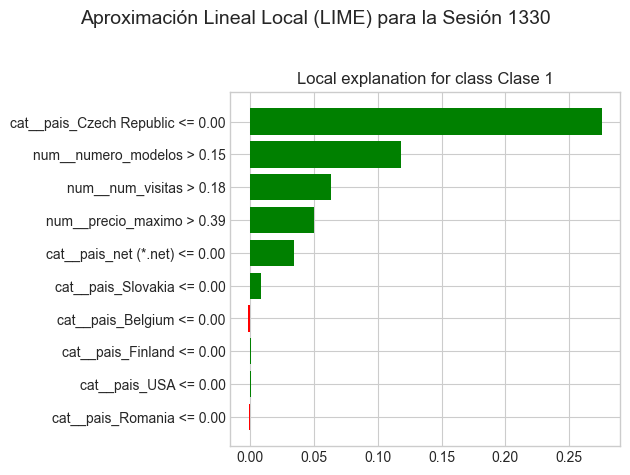

In [65]:
# Visualizamos los coeficientes del modelo local 'g'
# Estos NO son los coeficientes globales, son los coeficientes de la regresión ponderada local
print(f"Coeficientes del modelo local g(z) para la sesión {i}:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

figura_lime = exp.as_pyplot_figure()

# Es mejor usar el objeto figura devuelto por LIME para configurar el título
figura_lime.suptitle(
    f"Aproximación Lineal Local (LIME) para la Sesión {i}", 
    fontsize=14
)

# Nota: exp.as_pyplot_figure() maneja internamente la creación del plot.
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajusta el diseño para hacer espacio para el título
plt.show()

# 6. Conclusiones